In [33]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

import joblib


In [34]:
train_df = pd.read_csv("../data/processed/anomaly_dataset/train_processed.csv")
test_df = pd.read_csv("../data/processed/anomaly_dataset/test_processed.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (16561, 22)
Test shape: (4070, 22)


,engine_id,cycle,setting_1,setting_2,setting_3,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,...,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL,failure
0,2,1,-0.0018,0.0006,100.0,-1.581191,-1.092662,-1.963014,-7.193194,1.318090,...,-2.294365,1.242127,-0.500147,-0.315944,-1.373754,-1.426246,0.678684,1.564436,286,0
1,2,2,0.0043,-0.0003,100.0,-1.721722,-0.565155,-1.756664,0.139020,1.591518,...,-1.127747,1.745551,-1.615806,-0.654442,-0.675217,-0.779529,1.345844,1.098895,285,0
2,2,3,0.0018,0.0003,100.0,-2.263772,-0.356453,-1.106382,-7.193194,2.013053,...,-1.203012,1.582278,-1.476349,-0.169925,-1.648369,-1.426246,1.623827,1.252524,284,0
3,2,4,0.0035,-0.0004,100.0,-2.002785,-1.041719,-1.427619,0.139020,0.999091,...,-1.654606,1.459824,-2.313093,-0.177072,-1.072476,-1.426246,1.735021,1.975974,283,0
4,2,5,0.0005,0.0004,100.0,-1.902406,-1.883102,-0.709298,-7.193194,1.990267,...,-1.090114,1.160491,-2.173636,-0.369552,-1.475068,-2.072963,2.013004,1.237627,282,0


In [35]:
sensor_columns = []

for col in train_df.columns:
    if col.startswith("sensor_"):
        sensor_columns.append(col)


print("Number of sensors:", len(sensor_columns))
print(sensor_columns)

Number of sensors: 15
['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [36]:
HEALTHY_FRACTION = 0.30

healthy_rows = []

for engine_id, engine_data in train_df.groupby("engine_id"):

    engine_data = engine_data.sort_values("cycle")

    healthy_cycles = int(len(engine_data) * HEALTHY_FRACTION)

    healthy_engine_data = engine_data.iloc[:healthy_cycles]

    healthy_rows.append(healthy_engine_data)

healthy_train_df = pd.concat(healthy_rows, ignore_index=True)

print("Healthy training shape:", healthy_train_df.shape)

Healthy training shape: (4931, 22)


In [37]:
print("Total training rows:", len(train_df))
print("Healthy training rows:", len(healthy_train_df))
print("Healthy percentage:", round(len(healthy_train_df) / len(train_df) * 100, 2), "%")

Total training rows: 16561
Healthy training rows: 4931
Healthy percentage: 29.77 %


In [38]:
X_healthy = healthy_train_df[sensor_columns].values

print("Autoencoder input shape:", X_healthy.shape)

Autoencoder input shape: (4931, 15)


SandardScaler() uses $z = \frac{x - \mu}{\sigma}$, transforms every numerical feature has a mean of 0 and a standard deviation of 1. This process, called standardization, ensures all variables exist on a level playing field.

In [39]:
# Data is already scaled from processing.ipynb — no re-scaling needed
X_healthy_scaled = X_healthy

print("Scaled shape:", X_healthy_scaled.shape)

print("Mean:", X_healthy_scaled.mean().round(3))

print("Std:", X_healthy_scaled.std().round(3))

Scaled shape: (4931, 15)
Mean: -0.208
Std: 0.916


In [40]:
input_dim = X_healthy_scaled.shape[1]

input_layer = Input(shape=(input_dim,))

encoder = Dense(16, activation="relu")(input_layer)

encoder = Dense(8, activation="relu")(encoder)

decoder = Dense(16, activation="relu")(encoder)

output_layer = Dense(input_dim, activation="linear")(decoder)

autoencoder = Model(inputs=input_layer, outputs=output_layer)

autoencoder.compile(optimizer="adam", loss="mse")

autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 15)             │           255 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 791 (3.09 KB)

 Trainable params: 791 (3.09 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = autoencoder.fit(
    X_healthy_scaled,
    X_healthy_scaled,
    validation_split=0.2,
    epochs=100,
    batch_size=256,
    callbacks=[early_stopping],
    shuffle=True,
    verbose=1
)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 1.0655 - val_loss: 0.9102
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8878 - val_loss: 0.7840
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7829 - val_loss: 0.6864
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6880 - val_loss: 0.5834
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5832 - val_loss: 0.4801
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4849 - val_loss: 0.4031
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4168 - val_loss: 0.3636
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3777 - val_loss: 0.3404
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3540 - val_loss: 0.3239
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3377 - val_loss: 0.3116
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3242 - val_loss: 0.3002
Epoch 12/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.

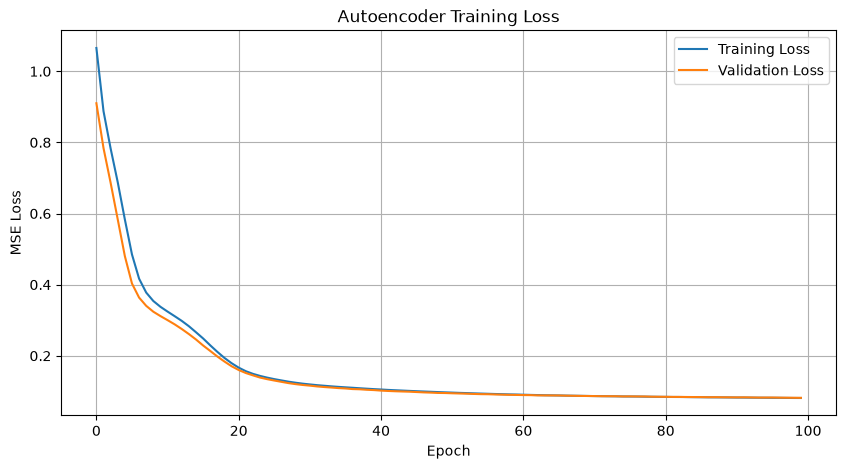

In [42]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss" )

plt.plot(history.history["val_loss"], label="Validation Loss" )

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training Loss")

plt.legend()
plt.grid(True)

plt.show()

In [43]:
healthy_reconstructed = autoencoder.predict(X_healthy_scaled, verbose=0)

healthy_errors = np.mean(np.square(X_healthy_scaled - healthy_reconstructed), axis=1)

print("Healthy reconstruction error:")
print("Mean:", healthy_errors.mean())
print("Median:", np.median(healthy_errors))
print("Maximum:", healthy_errors.max())

Healthy reconstruction error:
Mean: 0.08118545225221453
Median: 0.07089470485905223
Maximum: 0.6384643245373288


In [44]:
ANOMALY_PERCENTILE = 99

anomaly_threshold = np.percentile(healthy_errors, ANOMALY_PERCENTILE)

print("Anomaly threshold:", anomaly_threshold)

Anomaly threshold: 0.24342564509081852


In [45]:
def calculate_anomaly_score(data, sensor_columns, model):

    X = data[sensor_columns].values

    X_reconstructed = model.predict(X, verbose=0)

    reconstruction_error = np.mean(np.square(X - X_reconstructed), axis=1)
    
    return reconstruction_error

In [46]:
train_df["anomaly_score"] = calculate_anomaly_score(
    train_df,
    sensor_columns,
    autoencoder
)

test_df["anomaly_score"] = calculate_anomaly_score(
    test_df,
    sensor_columns,
    autoencoder
)

In [47]:
train_df["is_anomaly"] = (train_df["anomaly_score"] > anomaly_threshold).astype(int)

test_df["is_anomaly"] = (test_df["anomaly_score"] > anomaly_threshold).astype(int)

print("Train anomalies:", train_df["is_anomaly"].sum())

print("Test anomalies:", test_df["is_anomaly"].sum())

Train anomalies: 4248
Test anomalies: 1057


In [48]:
print("Test engines:")
print(sorted(test_df["engine_id"].unique()))

print("\nTrain engines:")
print(sorted(train_df["engine_id"].unique()))

Test engines:
[np.int64(1), np.int64(5), np.int64(11), np.int64(13), np.int64(19), np.int64(23), np.int64(31), np.int64(32), np.int64(34), np.int64(40), np.int64(45), np.int64(46), np.int64(54), np.int64(71), np.int64(74), np.int64(77), np.int64(78), np.int64(81), np.int64(84), np.int64(91)]

Train engines:
[np.int64(2), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(12), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(20), np.int64(21), np.int64(22), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(33), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63

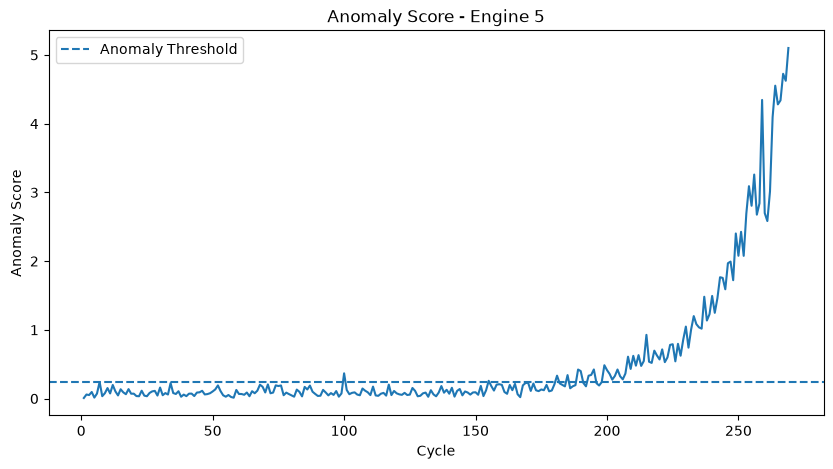

In [49]:
engine_id = 5

engine_data = test_df[test_df["engine_id"] == engine_id].sort_values("cycle")

plt.figure(figsize=(10, 5))

plt.plot(engine_data["cycle"], engine_data["anomaly_score"])

plt.axhline(anomaly_threshold, linestyle="--", label="Anomaly Threshold")

plt.xlabel("Cycle")
plt.ylabel("Anomaly Score")
plt.title(f"Anomaly Score - Engine {engine_id}")

plt.legend()
plt.show()

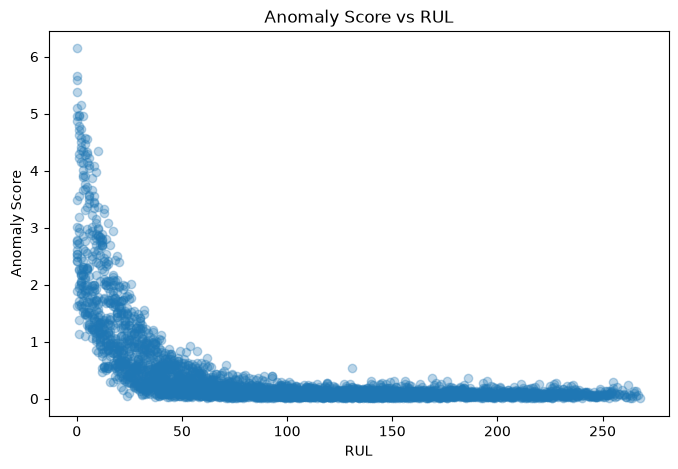

In [50]:
plt.figure(figsize=(8, 5))

plt.scatter(
    test_df["RUL"],
    test_df["anomaly_score"],
    alpha=0.3
)

plt.xlabel("RUL")
plt.ylabel("Anomaly Score")
plt.title("Anomaly Score vs RUL")


plt.show()

In [51]:
print(sensor_columns)

['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


test_df.iloc[0] = first row of test_df. ||| 
Autoencoder was trained only on [sensor_columns]  ||| 
converts those sensor values into .to_dict()

In [52]:
custom_input = test_df.iloc[0][sensor_columns].to_dict()

print(custom_input)

{'sensor_2': -1.7217222767762377, 'sensor_3': -0.1296742918751208, 'sensor_4': -0.923455644513689, 'sensor_6': 0.1390203039774327, 'sensor_7': 1.1244121844794452, 'sensor_8': -0.5132520808662693, 'sensor_9': -0.847746284710608, 'sensor_11': -0.2621914081794299, 'sensor_12': 0.3305228969268549, 'sensor_13': -1.0579765801194794, 'sensor_14': -0.2699935998174962, 'sensor_15': -0.6005640075159675, 'sensor_17': -0.7795285445408454, 'sensor_20': 1.3458441301403437, 'sensor_21': 1.1966589278737314}


In [53]:
def predict_anomaly(sensor_values):

    # Convert dictionary to DataFrame
    input_df = pd.DataFrame([sensor_values], columns=sensor_columns)

    # Scale using the SAME scaler used during training
    X_scaled = anomaly_scaler.transform(input_df[sensor_columns])

    # Reconstruct using trained Autoencoder
    X_reconstructed = autoencoder.predict(X_scaled, verbose=0)

    # Calculate reconstruction error
    anomaly_score = np.mean(np.square(X_scaled - X_reconstructed), axis=1)[0]

    # Classification
    if anomaly_score > anomaly_threshold:
        prediction = "ANOMALY"
    else:
        prediction = "NORMAL"

    return anomaly_score, prediction

In [54]:
score, prediction = predict_anomaly(custom_input)

print("Anomaly Score:", score)
print("Threshold:", anomaly_threshold)
print("Prediction:", prediction)

Anomaly Score: 0.21962680304975604
Threshold: 0.24342564509081852
Prediction: NORMAL


c:\Users\pawan\Desktop\InfosysSpringBoard\Industrial-Maintenance-and-Process-Optimization-System\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [55]:
autoencoder.save("../models/anomaly_autoencoder.keras")
joblib.dump(anomaly_threshold, "../models/anomaly_threshold.pkl")

['../models/anomaly_threshold.pkl']

In [56]:
train_df.to_csv("../data/processed/anomaly_dataset/train_anomaly_results.csv", index=False)

test_df.to_csv("../data/processed/anomaly_dataset/test_anomaly_results.csv", index=False)